# Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import geopandas as gpd

from mpl_toolkits.mplot3d import Axes3D

import gempy as gp
import gempy_viewer as gpv
import gempy_engine

from gempy_engine.core.data.stack_relation_type import StackRelationType
import HelperMethods

import threading
import pickle
import os

BASE_DIR = os.getcwd()
data_dir = os.path.abspath(os.path.join(BASE_DIR, '..', '..', 'Data', 'Input_Data'))
geomodel_dir = os.path.abspath(os.path.join(BASE_DIR, '..', '..', 'Data', 'Geological_Models'))

trigger_create_cross_section = True

Setting Backend To: AvailableBackends.numpy


# Model Parameters

In [2]:
# Model Extent
min_x = -707522
max_x = -677518
min_y =  4528453
max_y =  4549947
max_z =  505
model_depth = -500

# Set the extent of the model
extent=[min_x, max_x, max_y, min_y, model_depth, max_z]

# Set model resolution
nx = ny = nz = 64  # Define grid resolution
resolution = [nx, ny, nz]

# Topography
path_to_topography_reduced = os.path.join(data_dir, 'topo_reduced_sf0.1.tif')

# Load in and Visualise Data

In [3]:
plutonite_orientations_df = pd.read_csv(os.path.join(data_dir, 'Plutonic_Data', 'plutonic_orientations_points.csv'))
plutonite_points_df       = pd.read_csv(os.path.join(data_dir, 'Plutonic_Data', 'plutonic_contact_points.csv'))

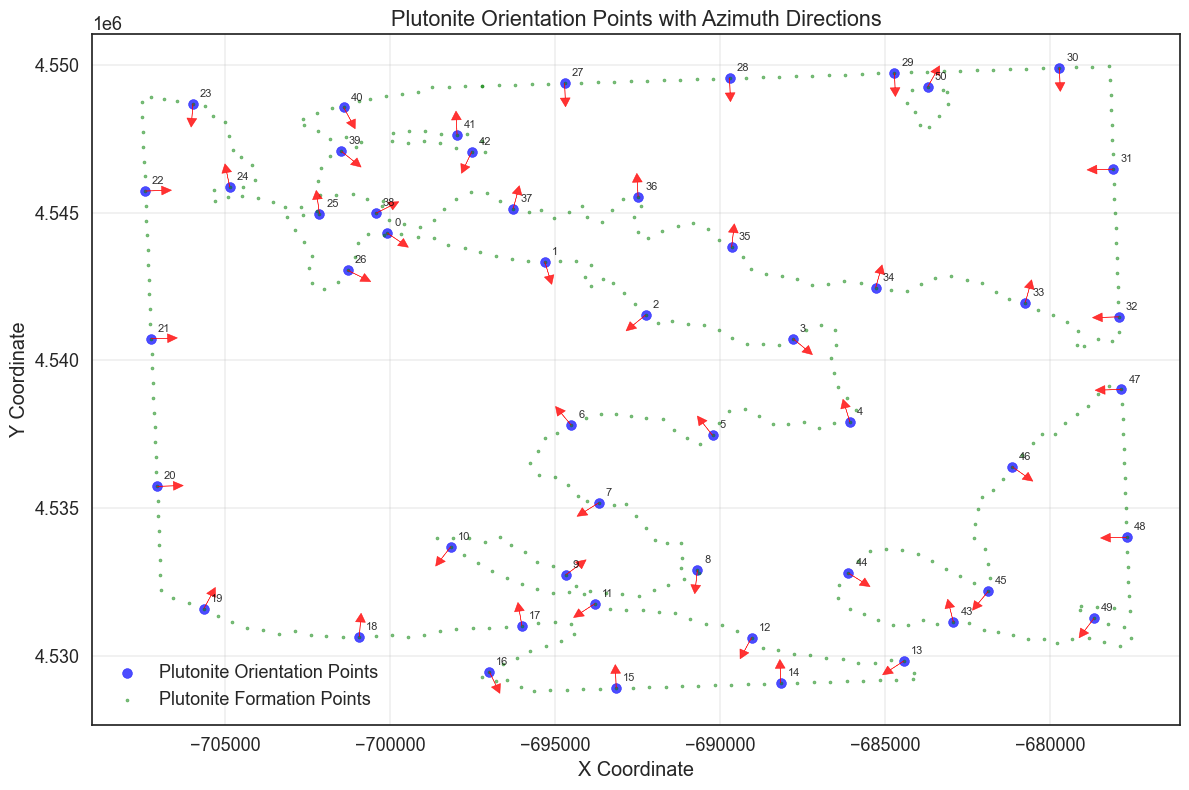

In [4]:
# Visualize plutonite orientations on a map
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the orientation points
scatter = ax.scatter(plutonite_orientations_df['X'], plutonite_orientations_df['Y'], 
                    c='blue', s=50, alpha=0.7, label='Plutonite Orientation Points')

# Also plot the formation points
scatter2 = ax.scatter(plutonite_points_df['X'], plutonite_points_df['Y'], 
                        c='green', s=20, alpha=0.5, label='Plutonite Formation Points', marker='.')

# Add arrows for azimuth directions
for idx, row in plutonite_orientations_df.iterrows():
    # Arrow parameters
    arrow_length = 500  # arrow length in map units
    azimuth_rad = np.deg2rad(row['azimuth'])  # Convert azimuth to radians
    dx = arrow_length * np.sin(azimuth_rad)
    dy = arrow_length * np.cos(azimuth_rad)
    
    # Draw arrow showing strike direction
    ax.arrow(row['X'], row['Y'], dx, dy, 
            head_width=300, head_length=300, fc='red', ec='red', alpha=0.8)

# Add annotations for each point showing its index number
for idx, row in plutonite_orientations_df.iterrows():
    ax.annotate(str(idx), (row['X'], row['Y']), 
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8, color='black')

ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_title('Plutonite Orientation Points with Azimuth Directions')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Grid Search Plutonite Model Perturbations

In [5]:
level_of_sampling_points        = np.array([0.9, 0.8, 0.7, 0.6, 0.5])                          # removing 90%, 80%, 70% etc...
level_of_sampling_orientations  = np.array([0.9, 0.8, 0.7])                                    # removing 90%, 80%, 70% etc...

# Cross Sections of Interest

In [6]:
# Set cross sections
section_dict = {'W-E_1': ([-710000,4.54750*1e6], [-675000,4.54750*1e6], [64,64]),
                'W-E_2': ([-710000,4.54000*1e6], [-675000,4.54000*1e6], [64,64]),
                'W-E_3': ([-710000,4.53500*1e6], [-675000,4.53500*1e6], [64,64]),
                'W-E_4': ([-710000,4.5325*1e6], [-675000,4.5325*1e6], [64,64]),
                
                'N-S_1': ([-707500,4.530*1e6], [-707500,4.550*1e6], [64,64]),
                'N-S_2': ([-697500,4.530*1e6], [-697500,4.550*1e6], [64,64]),
                'N-S_3': ([-690000,4.530*1e6], [-690000,4.550*1e6], [64,64]),
                'N-S_4': ([-682500,4.530*1e6], [-682500,4.550*1e6], [64,64])}

In [7]:
list(section_dict.keys())[0]

'W-E_1'

# Creating Folder Structure for saving Perturbation Images

In [ ]:

# Create main results folder and subfolder structure before loops
main_results_folder = "Perturbation Results"
if not os.path.exists(main_results_folder):
    os.makedirs(main_results_folder)

# Create subfolder structure for all combinations
for sampling in level_of_sampling_points:
    sampling_folder = os.path.join(main_results_folder, f"Sampling_Points_{int(sampling*100)}pct")
    if not os.path.exists(sampling_folder):
        os.makedirs(sampling_folder)
    
    for orientations in level_of_sampling_orientations:
        orientations_folder = os.path.join(sampling_folder, f"Sampling_Orientations_{int(orientations*100)}pct")
        if not os.path.exists(orientations_folder):
            os.makedirs(orientations_folder)

print(f"Main folder: {main_results_folder}")

# Calculating Perturbation Results

Indices 0-26: West Plutonite

..........

Indices 27-40: North East Plutonite

Indices 41-42:North East Plutonite

Indices 50: North East Plutonite

..........

Indices 43-49:South East Plutonite

In [16]:
# Set mean and std for dip angle perturbations
dip_angle_mean = {"West Plutonite": 80, "North-East Plutonite": 60, "South Plutonite": 40}
dip_angle_std  = {"Very random": 5, "Mildly random": 2.5, "Little random": 1}

# Load the data
plutonite_orientations_df_path = os.path.join(data_dir, 'Plutonic_Data',    'plutonic_orientations_points.csv')
plutonite_points_df_path       = os.path.join(data_dir, 'Plutonic_Data',    'plutonic_contact_points.csv')
topography_path                = os.path.join(data_dir, 'Topographic_Data', 'topo_reduced_sf0.1.tif')

# Where to store the results
results_folder = os.path.join(geomodel_dir, 'Plutonite-Perturbed_Models')

In [23]:
from plutonic_perturbations import plutonic_perturbations

plutonic_perturbations(level_of_sampling_points, level_of_sampling_orientations, 
                       section_dict,
                       plutonite_orientations_df_path, plutonite_points_df_path,
                       topography_path,
                       results_folder)
                       

TypeError: plutonic_perturbations() takes 3 positional arguments but 7 were given

In [ ]:
# plutonite_orientations_df = pd.read_csv("sampled_orientationinputpoints10_perfect.csv")
# # Make a copy of the orientations DataFrame
# plutonite_orientations_df = plutonite_orientations_df.copy()

# method_name = "mildly random"

# # Assign dip angles based on the chosen method
# if method_name == "purely random":
#     # Very random
#     std = 5
#     plutonite_orientations_df.loc[0:26,  'dip']    = np.random.normal(80, std, size=27)     # indices 0 to 26
#     plutonite_orientations_df.loc[27:40, 'dip']    = np.random.normal(60, std, size=14)     # indices 27 to 40
#     plutonite_orientations_df.loc[41:42, 'dip']    = np.random.normal(60, std, size=2)      # indices 41 to 42
#     plutonite_orientations_df.loc[43:49, 'dip']    = np.random.normal(40, std, size=7)      # indices 43 to 49
#     plutonite_orientations_df.loc[50,    'dip']    = np.random.normal(60, std, size=1)      # index 50 only
# elif method_name == "mildly random":
#     # Midly random
#     std = 2.5
#     plutonite_orientations_df.loc[0:26,  'dip']    = np.random.normal(80, std, size=27)     # indices 0 to 26
#     plutonite_orientations_df.loc[27:40, 'dip']    = np.random.normal(60, std, size=14)     # indices 27 to 40
#     plutonite_orientations_df.loc[41:42, 'dip']    = np.random.normal(60, std, size=2)      # indices 41 to 42
#     plutonite_orientations_df.loc[43:49, 'dip']    = np.random.normal(40, std, size=7)      # indices 43 to 49
#     plutonite_orientations_df.loc[50,    'dip']    = np.random.normal(60, std, size=1)      # index 50 only
# elif method_name == "little random":
#     # Little random
#     std = 1
#     plutonite_orientations_df.loc[0:26,  'dip']    = np.random.normal(80, std, size=27)     # indices 0 to 26
#     plutonite_orientations_df.loc[27:40, 'dip']    = np.random.normal(60, std, size=14)     # indices 27 to 40
#     plutonite_orientations_df.loc[41:42, 'dip']    = np.random.normal(60, std, size=2)      # indices 41 to 42
#     plutonite_orientations_df.loc[43:49, 'dip']    = np.random.normal(40, std, size=7)      # indices 43 to 49
#     plutonite_orientations_df.loc[50,    'dip']    = np.random.normal(60, std, size=1)      # index 50 only


# # Clip the values to ensure they're between 0 and 90
# plutonite_orientations_df['dip'] = np.clip(plutonite_orientations_df['dip'], 0, 90)

In [ ]:

# # Visualize plutonite orientations on a map
# fig, ax = plt.subplots(figsize=(12, 8))

# # Plot the orientation points
# scatter = ax.scatter(plutonite_orientations_df['X'], plutonite_orientations_df['Y'], 
#                     c='blue', s=50, alpha=0.7, label='Plutonite Orientation Points')

# # Also plot the formation points
# scatter2 = ax.scatter(plutonite_points_df['X'], plutonite_points_df['Y'], 
#                         c='green', s=20, alpha=0.5, label='Plutonite Formation Points', marker='.')

# # Add arrows for azimuth directions
# for idx, row in plutonite_orientations_df.iterrows():
#     # Arrow parameters
#     arrow_length = 500  # arrow length in map units
#     azimuth_rad = np.deg2rad(row['azimuth'])  # Convert azimuth to radians
#     dx = arrow_length * np.sin(azimuth_rad)
#     dy = arrow_length * np.cos(azimuth_rad)
    
#     # Draw arrow showing strike direction
#     ax.arrow(row['X'], row['Y'], dx, dy, 
#             head_width=300, head_length=300, fc='red', ec='red', alpha=0.8)

# # Add annotations for each point showing its dip angle
# for idx, row in plutonite_orientations_df.iterrows():
#     ax.annotate(f"{row['dip']:.1f}°", (row['X'], row['Y']), 
#                 xytext=(5, 5), textcoords='offset points',
#                 fontsize=8, alpha=0.8, color='black')

# ax.set_xlabel('X Coordinate')
# ax.set_ylabel('Y Coordinate')
# ax.set_title('Plutonite Orientation Points with Azimuth Directions')
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [ ]:
# # Create the 2D plot using imshow with masked zeros
# fig, ax = plt.subplots(figsize=(12, 10))

# # Use imshow for a pixel-based representation with masked zeros
# im = ax.imshow(plutonite_count_2d_masked.T, 
#             extent=[min_x/1000, max_x/1000, min_y/1000, max_y/1000], 
#             cmap='plasma', 
#             origin='lower', 
#             interpolation='nearest', 
#             alpha=0.9)

# # Add colorbar
# cbar = plt.colorbar(im, ax=ax, shrink=0.8)
# cbar.set_label('Number of Plutonite Voxels in Vertical Stack', fontsize=12)

# # Set labels and title
# ax.set_xlabel('X Coordinate (km)', fontsize=12)
# ax.set_ylabel('Y Coordinate (km)', fontsize=12)
# ax.set_title(f'Plutonite Thickness\n{param_combination}', fontsize=14, pad=20)

# # Set aspect ratio to be equal
# ax.set_aspect('equal')

# # Add grid
# ax.grid(True, alpha=0.3, linestyle='--', color='black')